<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

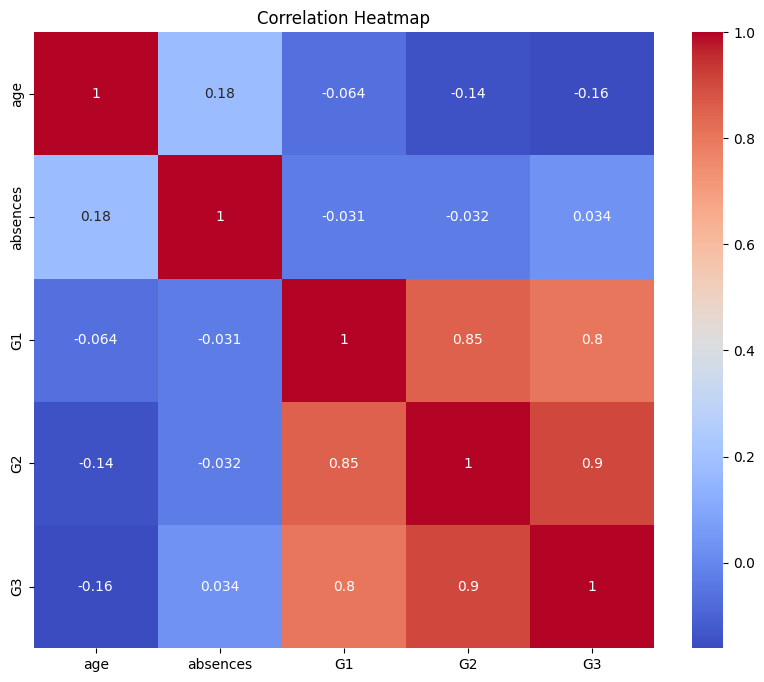

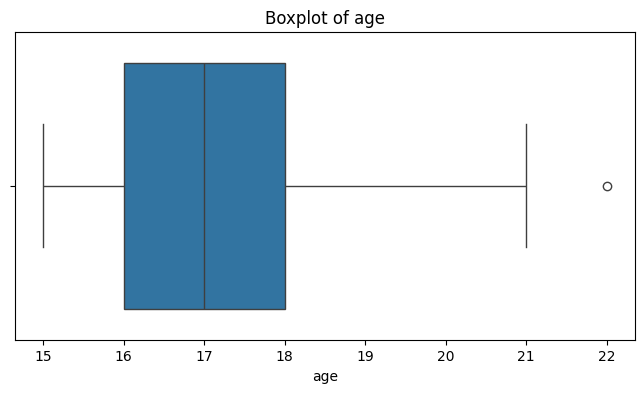

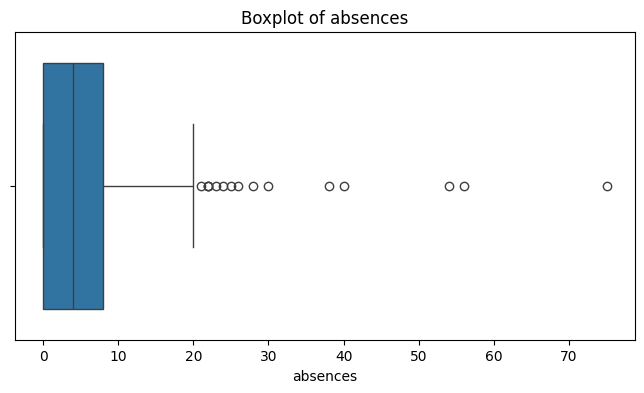

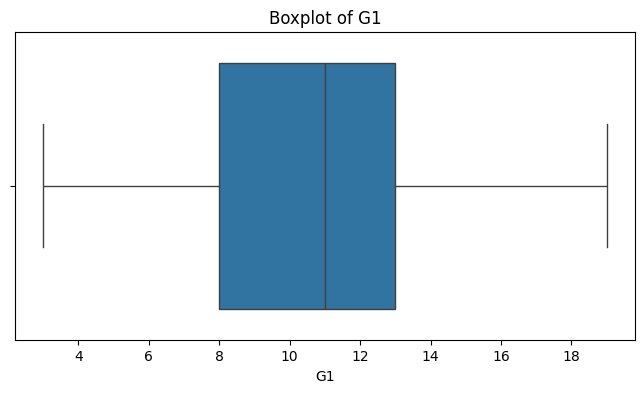

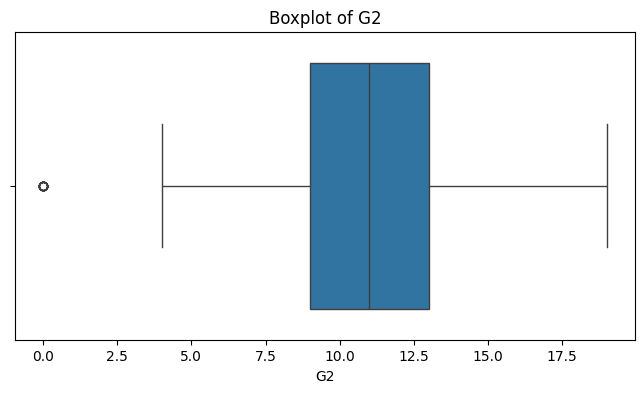

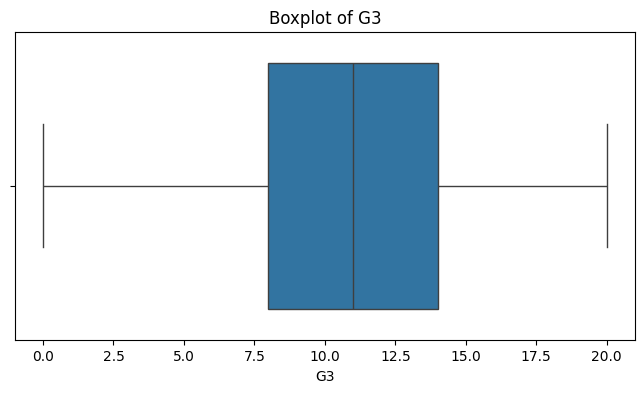

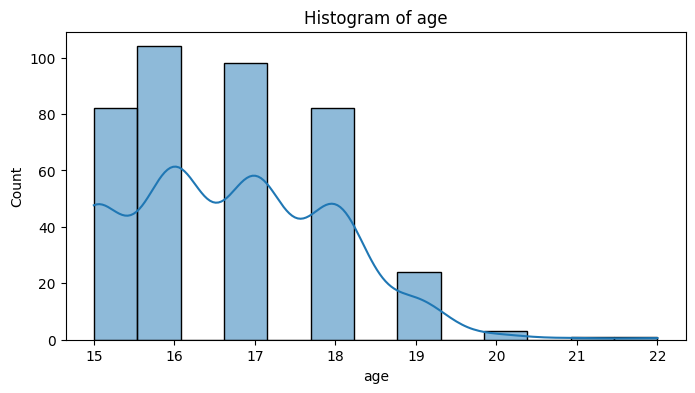

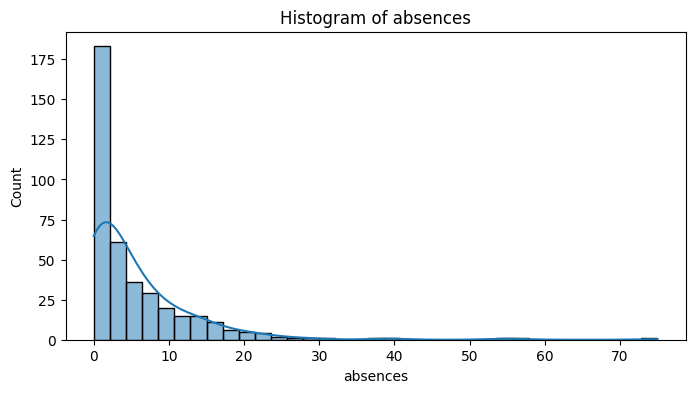

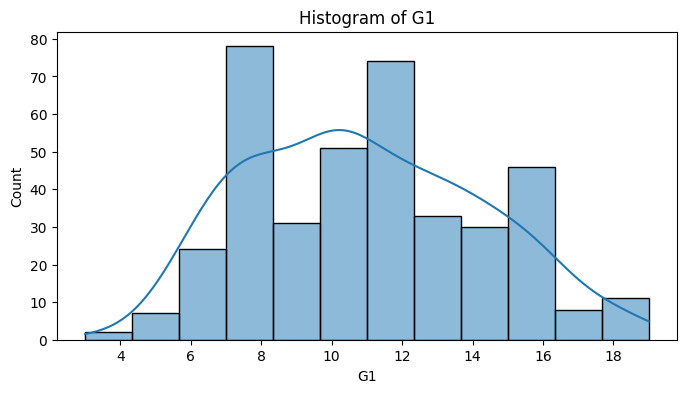

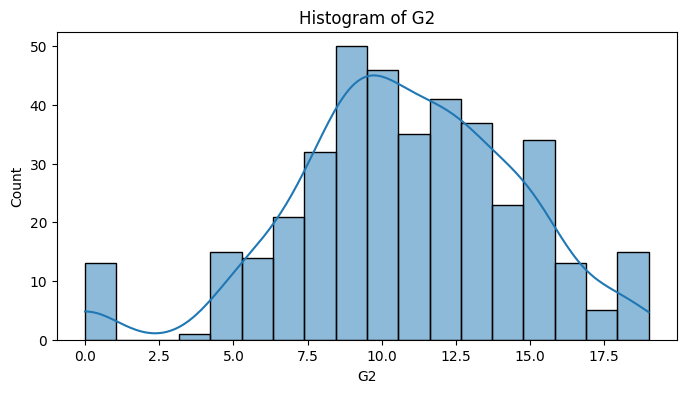

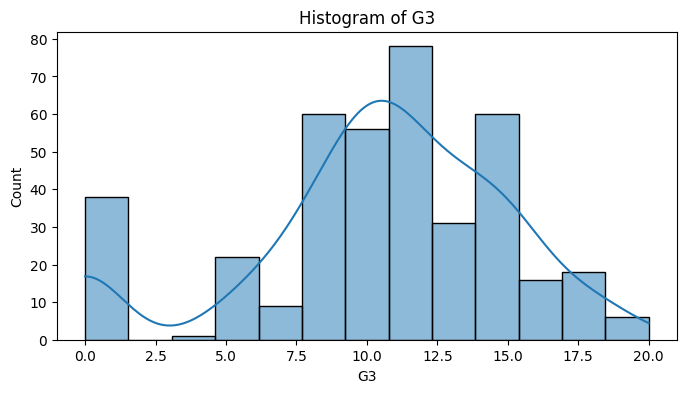

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('student.csv', sep=';')

# Check quality data
print(df.info())
print(df.head())

pd.set_option('display.max_columns', None) # We need to see all feature
print(df.describe())

# Check missing values and duplicated
print( 'Missing values:\n', df.isnull().sum().sort_values(ascending=False))
print( 'Duplicated:', df.duplicated().sum())
print( 'The data is clean')

# Visualize the data
# Correlation heatmap for numerical features
numerical_features = ['age', 'absences', 'G1', 'G2', 'G3']
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot for numerical features
for feature in numerical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

# Histogram for numerical features
for feature in numerical_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.show()




In [3]:
# There is extreme outliers in absence feature, but it's still have value, so use winsorizing is the best thing to do
print('before winsorizing:')
print(df['absences'].describe())
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Cap the outliers
df['absences'] = df['absences'].clip(lower=lower, upper=upper)

# Verify
print('after winsorizing:')
print(df['absences'].describe())

before winsorizing:
count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64
after winsorizing:
count    395.000000
mean       5.187342
std        5.694448
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       20.000000
Name: absences, dtype: float64


In [ ]:
# Encode categorical
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Split after encoding
x = df.drop('G3', axis=1)
y = df['G3']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Modelling
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regression': SVR(),
    'KNN Regressor': KNeighborsRegressor(),
    'Random Forest regressor': RandomForestRegressor(random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=42),
}
results = []
pipelines = {}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Pipeline
for name, method in models.items():
    main_pipeline = Pipeline([
        ('Scaler', RobustScaler()),
        ('Models', method)
    ])
    main_pipeline.fit(x_train, y_train)
    predict = main_pipeline.predict(x_test)
    scores = cross_val_score(main_pipeline, x_train, y_train, cv=kf, scoring='r2')
    pipelines[name] = main_pipeline  
    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, predict),
        'RMSE': root_mean_squared_error(y_test, predict),
        'CV R2 Mean': scores.mean(),
        'CV R2 Std': scores.std()
    })

# Evaluate Result
evaluate = pd.DataFrame(results)

evaluate = evaluate.sort_values(by='R2 Score', ascending=False)
result_table = evaluate[['Model', 'RMSE', 'R2 Score', 'CV R2 Mean', 'CV R2 Std']].copy()
result_table.columns = ['Model', 'RMSE', 'R2', 'CV Mean', 'CV Std']

# Format numbers
result_table['RMSE'] = result_table['RMSE'].map(lambda x: f"{x:.2f}")
result_table['R2'] = result_table['R2'].map(lambda x: f"{x:.3f}")
result_table['CV Mean'] = result_table['CV Mean'].map(lambda x: f"{x:.3f}")
result_table['CV Std'] = result_table['CV Std'].map(lambda x: f"{x:.3f}")

# Print tabel
print(result_table.to_markdown(index=False))

| Model                     |   RMSE |    R2 |   CV Mean |   CV Std |
|:--------------------------|-------:|------:|----------:|---------:|
| Random Forest regressor   |   1.95 | 0.815 |     0.89  |    0.051 |
| Hist Gradient Boosting    |   1.97 | 0.81  |     0.871 |    0.058 |
| Support Vector Regression |   2.36 | 0.727 |     0.691 |    0.086 |
| Linear Regression         |   2.37 | 0.726 |     0.817 |    0.047 |
| KNN Regressor             |   3.23 | 0.49  |     0.627 |    0.09  |


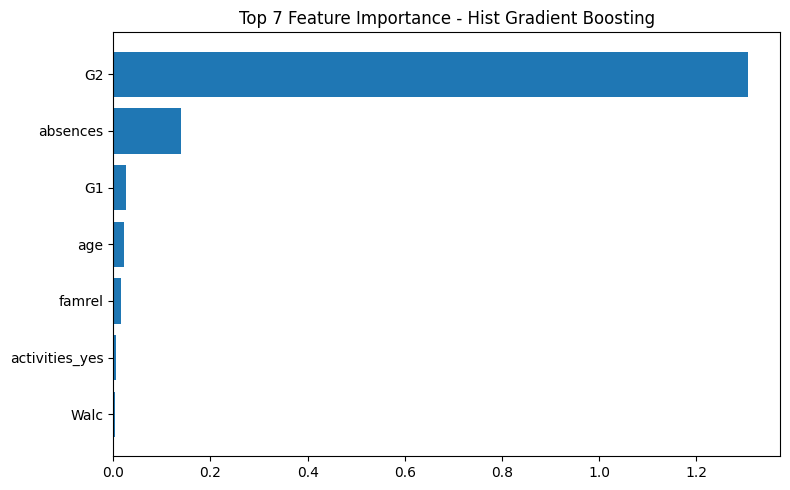

In [ ]:
# Top 7 Feature Importance - Hist Gradient Boosting
from sklearn.inspection import permutation_importance

perm = permutation_importance(pipelines['Hist Gradient Boosting'], x_test, y_test, n_repeats=10, random_state=42)

fi_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False).head(7)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1])
plt.title('Top 7 Feature Importance - Hist Gradient Boosting')
plt.tight_layout()
plt.show()